In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Step 1: Loading dataset...")
df = pd.read_csv("/content/KaggleV2-May-2016.csv")
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.\n")

print("Sample data (first 5 rows):")
print(df.head())

Step 1: Loading dataset...
Dataset loaded with 75434 rows and 14 columns.

Sample data (first 5 rows):
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13      5642903.0      F  2016-04-29T18:38:08Z   
1  5.589978e+14      5642503.0      M  2016-04-29T16:08:27Z   
2  4.262962e+12      5642549.0      F  2016-04-29T16:19:04Z   
3  8.679512e+11      5642828.0      F  2016-04-29T17:29:31Z   
4  8.841186e+12      5642494.0      F  2016-04-29T16:07:23Z   

         AppointmentDay   Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z  62.0    JARDIM DA PENHA          0.0           1.0   
1  2016-04-29T00:00:00Z  56.0    JARDIM DA PENHA          0.0           0.0   
2  2016-04-29T00:00:00Z  62.0      MATA DA PRAIA          0.0           0.0   
3  2016-04-29T00:00:00Z   8.0  PONTAL DE CAMBURI          0.0           0.0   
4  2016-04-29T00:00:00Z  56.0    JARDIM DA PENHA          0.0           1.0   

   Diabetes  Alcoholism  Handcap  SMS_recei

In [ ]:
print("Step 2: Dropping 'PatientId' and 'AppointmentID' (unique IDs, not useful for prediction).")
print(f"Columns before: {df.columns.tolist()}")
df.drop(['PatientId', 'AppointmentID'], axis=1, inplace=True)
print(f"Columns after: {df.columns.tolist()}\n")


Step 2: Dropping 'PatientId' and 'AppointmentID' (unique IDs, not useful for prediction).
Columns before: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']
Columns after: ['Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']



Step 3: Convert date columns and create 'WaitingDays' feature.
Sample of new 'WaitingDays' feature:
               ScheduledDay            AppointmentDay  WaitingDays
0 2016-04-29 18:38:08+00:00 2016-04-29 00:00:00+00:00         -1.0
1 2016-04-29 16:08:27+00:00 2016-04-29 00:00:00+00:00         -1.0
2 2016-04-29 16:19:04+00:00 2016-04-29 00:00:00+00:00         -1.0
3 2016-04-29 17:29:31+00:00 2016-04-29 00:00:00+00:00         -1.0
4 2016-04-29 16:07:23+00:00 2016-04-29 00:00:00+00:00         -1.0
Dropped original date columns.



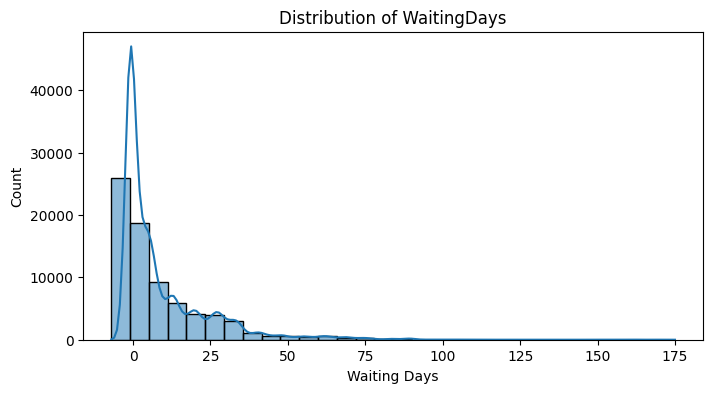

In [ ]:
print("Step 3: Convert date columns and create 'WaitingDays' feature.")

df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['WaitingDays'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

print("Sample of new 'WaitingDays' feature:")
print(df[['ScheduledDay', 'AppointmentDay', 'WaitingDays']].head())

df.drop(['ScheduledDay', 'AppointmentDay'], axis=1, inplace=True)
print("Dropped original date columns.\n")

plt.figure(figsize=(8,4))
sns.histplot(df['WaitingDays'], bins=30, kde=True)
plt.title("Distribution of WaitingDays")
plt.xlabel("Waiting Days")
plt.ylabel("Count")
plt.show()


Step 4: Removing rows with negative WaitingDays and Age outliers.
Shape before cleaning: (75434, 11)
Shape after cleaning: (49486, 11)



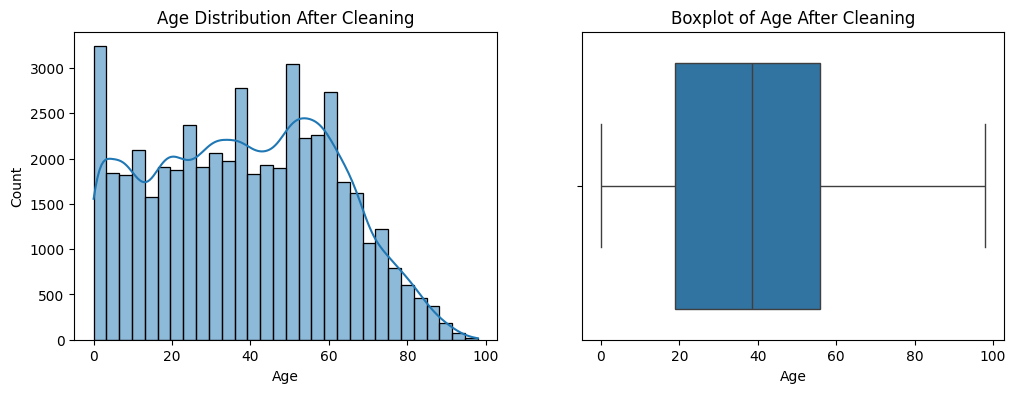

In [ ]:
print("Step 4: Removing rows with negative WaitingDays and Age outliers.")

print(f"Shape before cleaning: {df.shape}")
df = df[(df['WaitingDays'] >= 0) & (df['Age'] >= 0) & (df['Age'] <= 100)]
print(f"Shape after cleaning: {df.shape}\n")

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution After Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age After Cleaning")

plt.show()


In [ ]:
print("Step 5: Encoding 'Gender' and 'No-show' columns.")

print(f"Gender unique values before encoding: {df['Gender'].unique()}")
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})
print(f"Gender unique values after encoding: {df['Gender'].unique()}")
print(f"No-show unique values after encoding: {df['No-show'].unique()}\n")


Step 5: Encoding 'Gender' and 'No-show' columns.
Gender unique values before encoding: ['F' 'M']
Gender unique values after encoding: [0 1]
No-show unique values after encoding: [0 1]



In [ ]:
print("Step 6: One-hot encoding 'Neighbourhood' column.")

print(f"Number of unique neighbourhoods before encoding: {df['Neighbourhood'].nunique()}")
df = pd.get_dummies(df, columns=['Neighbourhood'], drop_first=True)
print(f"Total features after encoding: {df.shape[1]}\n")


Step 6: One-hot encoding 'Neighbourhood' column.
Number of unique neighbourhoods before encoding: 80
Total features after encoding: 89



Step 7: Splitting features and target.
Feature matrix shape: (49486, 88)
Target vector shape: (49486,)

Step 8: Scaling features.
Feature scaling completed.



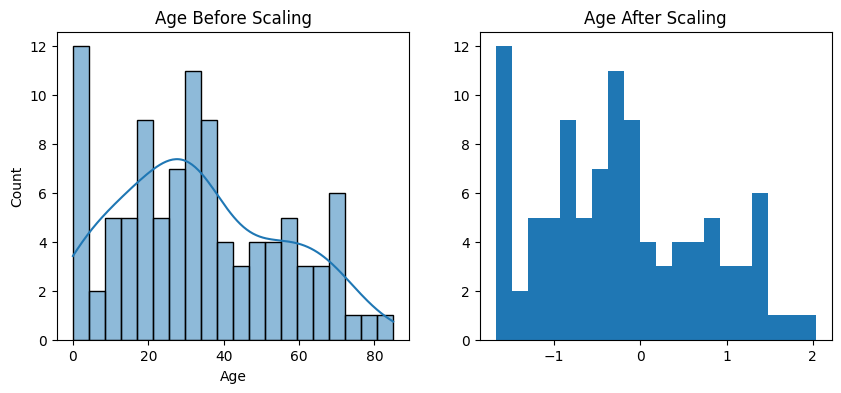

In [ ]:
from sklearn.preprocessing import StandardScaler

print("Step 7: Splitting features and target.")
X = df.drop('No-show', axis=1)
y = df['No-show']
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}\n")

print("Step 8: Scaling features.")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling completed.\n")

# Visualize Age before and after scaling (first 100 samples)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(X['Age'][:100], bins=20, kde=True)
plt.title("Age Before Scaling")

plt.subplot(1,2,2)
plt.hist(X_scaled[:100, X.columns.get_loc('Age')], bins=20)
plt.title("Age After Scaling")

plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

print("Step 9: Splitting into train and test sets.")
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}\n")


Step 9: Splitting into train and test sets.
Training samples: 39588
Testing samples: 9898



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Step 10: Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression training completed.\n")

print("Step 11: Training Random Forest with tuned hyperparameters...")
rf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest training completed.\n")


Step 10: Training Logistic Regression...
Logistic Regression training completed.

Step 11: Training Random Forest with tuned hyperparameters...
Random Forest training completed.



Step 12: Evaluating Logistic Regression...
Accuracy: 71.42%
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      7064
           1       0.56      0.01      0.02      2834

    accuracy                           0.71      9898
   macro avg       0.64      0.50      0.42      9898
weighted avg       0.67      0.71      0.60      9898

Step 13: Evaluating Random Forest...
Accuracy: 71.52%
              precision    recall  f1-score   support

           0       0.72      1.00      0.83      7064
           1       0.64      0.01      0.02      2834

    accuracy                           0.72      9898
   macro avg       0.68      0.50      0.43      9898
weighted avg       0.69      0.72      0.60      9898

Step 14: Confusion Matrix for Random Forest:


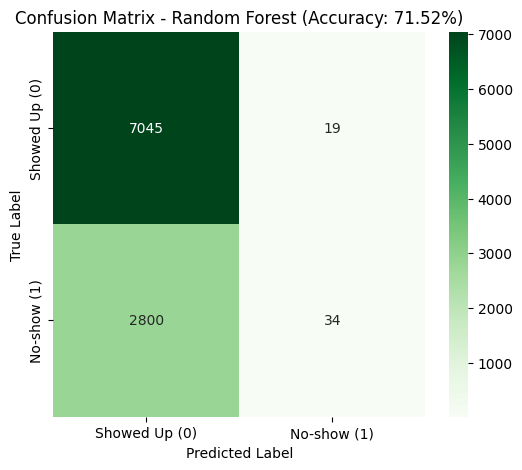

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Step 12: Evaluating Logistic Regression...")
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {acc_lr*100:.2f}%")
print(classification_report(y_test, y_pred_lr))

print("Step 13: Evaluating Random Forest...")
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy: {acc_rf*100:.2f}%")
print(classification_report(y_test, y_pred_rf))

print("Step 14: Confusion Matrix for Random Forest:")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Showed Up (0)', 'No-show (1)'],
            yticklabels=['Showed Up (0)', 'No-show (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Random Forest (Accuracy: {acc_rf*100:.2f}%)")
plt.show()


Step 15: Plotting top 20 feature importances from Random Forest.


<ipython-input-13-52c458a2bd1c>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


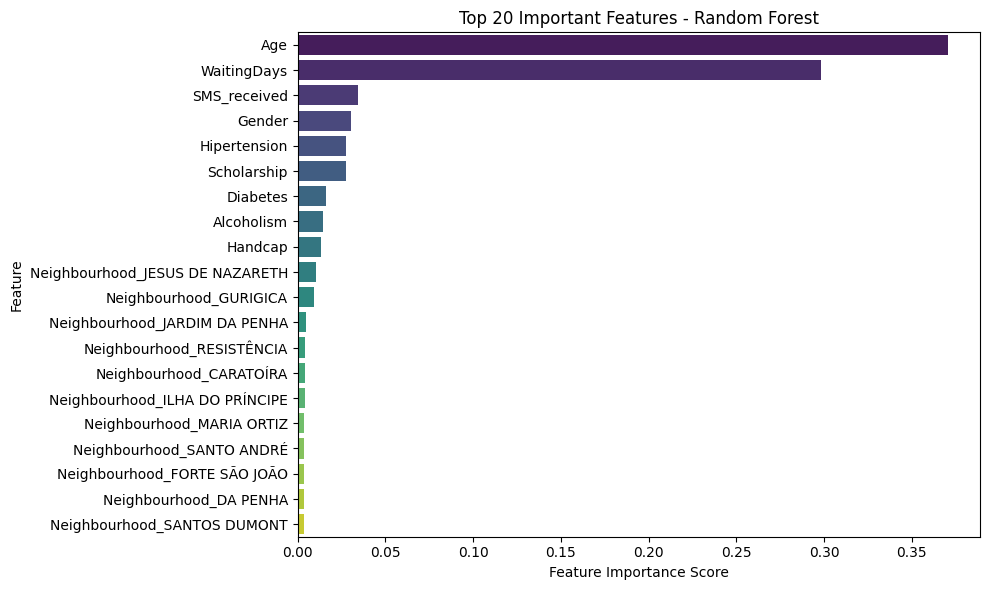

In [ ]:
import seaborn as sns

print("Step 15: Plotting top 20 feature importances from Random Forest.")
importances = rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title("Top 20 Important Features - Random Forest")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Step 11: Training Random Forest with tuned hyperparameters...


NameError: name 'X_train' is not defined